# Multi-trait founder GWAS across sites — joint / global / climate selection

**One GWAS, run across many gardens, with each garden used as a separate "trait."** The question
this whole thread chases: across climates, can we separate *"this allele is just generally good"*
(**generalist**) from *"this allele is good specifically where it's hot/cold"* (**climate-differential /
local adaptation**) — after removing the founder-relatedness background that makes clades and alleles
collinear?

*Test units = dynld-K500 LD blocks.*

## The model

A two-layer design. The **individuals are the 231 panel founders** (ecotypes) — *not* pools or plots,
which sidesteps plot pseudoreplication. The **"trait" is a per-founder selection coefficient**, and we
have one such trait **per site**.

**The trait (one vector per site, length 231).** For a given garden, each founder's genome-wide
frequency trajectory $p_0\!\to\!\text{gen}_1(\!\to\!\text{gen}_2\!\to\!\text{gen}_3)$ — flower-weighted,
pooled across that site's plots — is reduced to an **OLS selection slope** $s_f$ over time. So $s_f$ =
*who got selected, and how hard*, at that site. Then quantile-normalized. Each site uses its **full
available trajectory** (a single-year site → $p_0\!\to\!\text{gen}_1$; a surviving site →
$p_0\!\to\!\dots\!\to\!\text{gen}_3$), with $\text{gen}_1$ as the required anchor.

> **Caveat (documented, not hidden):** a variable per-site window correlates with climate (hot sites
> die at gen1, cold sites survive to gen3), so window length *alone* could fake a climate signal. The
> permutation null below does **not** remove this (it shuffles climate, not window length) — so the
> `TRAIT_GENS=1` uniform-window run is kept as the immune sensitivity check. Reassuringly
> $\lambda_{\text{clim}}=$1.01 here, i.e. the confound did **not** manufacture inflation.

**Layer 1 — per-site kinship-corrected GWAS (EMMAX/P3D).** For each site separately, a mixed-model
scan of $s_f$ on each haploblock allele:
$\;\mathbf y=\mu\mathbf 1+\mathbf x_b\beta_b+\mathbf u+\boldsymbol\varepsilon,\;
\mathbf u\sim\mathcal N(\mathbf 0,\sigma_g^2\mathbf K_{\text{LOCO}})$. $\mathbf K$ = founder GRM from
**common** markers (MAF≥5%), leave-one-chromosome-out (the tested chromosome is never in its own
correction). $\mathbf K$ is the structure control — it stops a whole clade's coordinated frequency
change from masquerading as a per-marker hit. Each site's $z$'s are genomic-controlled. Output: a matrix
$\mathbf Z$ (**markers × sites**) of calibrated per-marker effects.

**Layer 2 — Bolormaa (2014) multi-trait meta-analysis.** Estimate the cross-site null covariance
$\mathbf C=\mathrm{corr}(\mathbf Z)$ over the genome (under sparse signal ≈ the null site correlation;
mean off-diagonal ≈ 0.38), then form three $\mathbf C^{-1}$-whitened contrasts of each marker's
effect-vector $\mathbf z_b$:

| Contrast | Statistic | Tests |
|---|---|---|
| **JOINT** ($S$ df) | $Q=\mathbf z_b^{\mathsf T}\mathbf C^{-1}\mathbf z_b\sim\chi^2_{S}$ | selected at **any** site (omnibus) |
| **GLOBAL** (1 df) | $\mathbf 1^{\mathsf T}\mathbf C^{-1}\mathbf z_b/\sqrt{\mathbf 1^{\mathsf T}\mathbf C^{-1}\mathbf 1}\sim N(0,1)$ | **generalist** — same direction everywhere |
| **CLIMATE** (1 df) | $\mathbf c^{\mathsf T}\mathbf C^{-1}\mathbf z_b/\sqrt{\mathbf c^{\mathsf T}\mathbf C^{-1}\mathbf c}\sim N(0,1)$ | **climate-differential** — effect tracks site bio1 |

The climate vector $\mathbf c$ = standardized site bio1, $\mathbf C^{-1}$-orthogonalized against the
all-ones (GLOBAL) vector, so generalist and local-adaptation signal **partition cleanly** — neither
leaks into the other.

**Result (read with the figures).** The full-trajectory trait *sharpens* selection: JOINT has real
among-site hits (6 Bonferroni / 22 FDR) and GLOBAL surfaces the strongest **generalist
locus** (best $q\approx$1e-9) — but **CLIMATE localizes to nothing** (0 FDR hits, best
$q=$0.17). STAGE 2 (10k site-climate permutations) makes this rigorous: **no block is
genome-wide-significant for climate** (FWER $p=$0.26) and the diffuse excess is only marginal/NS
($p=$0.088) — yet at the **clade** level, which kinship-clade wins *does* track climate
(winning-clade PC1 vs bio1 on the **same 30 sites**, $|r|=$0.47, perm $p=$0.008).
So **climate-differential selection is real but lives at the clade level, not at resolvable loci** — the
clade↔allele collinearity wall, *demonstrated* rather than asserted. The selection that localizes is
generalist + among-site, not climate.

## Load the precomputed solution (STAGE 1 + STAGE 2)

In [1]:
import os, json
import numpy as np, pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
os.chdir("/global/scratch/users/tbellg/kmate")
H = "results/grenenet_gea/hapfreq"; CHROMS = ["Chr1","Chr2","Chr3","Chr4","Chr5"]
SUFFIX = ""; BLOCKS = "dynld-K500 LD blocks"

In [2]:
g    = pd.read_csv(f"{H}/multisite_founder_gwas{SUFFIX}.csv")          # per-block joint/global/climate p,q,z
meta = json.load(open(f"{H}/multisite_founder_gwas{SUFFIX}_meta.json"))
perm = json.load(open(f"{H}/multisite_climate_perm{SUFFIX}.json"))
# numeric npz arrays only (the `chrom` key is a pickled object array -> skip it; coords come from g)
npz  = np.load(f"{H}/multisite_founder_gwas{SUFFIX}.npz")
Z, sites, bio1, C = npz["Z"], npz["sites"], npz["bio1"], npz["C"]
m = len(g); bonf = 0.05/m; S = meta["S"]; T = meta["tests"]
print(f"{meta['n_founders']} founders | {m:,} test blocks (MAF>={meta['mac_min']/meta['n_founders']:.1%}) "
      f"x {S} sites | trait gens (full trajectory) = {meta['trait_gens']}")
print(f"excluded site(s): {meta['excluded_sites']} | mean cross-site C off-diag = {meta['mean_cross_site_C']:.2f}")
print()
for k in ["JOINT","GLOBAL","CLIMATE"]:
    t = T[k]
    print(f"  {k:7s}  lambda_GC={t['lam']:.2f} | Bonferroni {t['n_bonf']:>2d} | "
          f"FDR q<.05 {t['n_fdr']:>2d} ({t['n_fdr_common']} common) | best q={t['best_q']:.2g}")

231 founders | 41,114 test blocks (MAF>=1.3%) x 30 sites | trait gens (full trajectory) = [1, 2, 3]
excluded site(s): [33] | mean cross-site C off-diag = 0.38

  JOINT    lambda_GC=1.12 | Bonferroni  6 | FDR q<.05 22 (8 common) | best q=5.6e-05
  GLOBAL   lambda_GC=1.00 | Bonferroni  1 | FDR q<.05  1 (0 common) | best q=9.9e-10
  CLIMATE  lambda_GC=1.01 | Bonferroni  0 | FDR q<.05  0 (0 common) | best q=0.17


## STAGE 1 — Manhattan: joint / global / climate

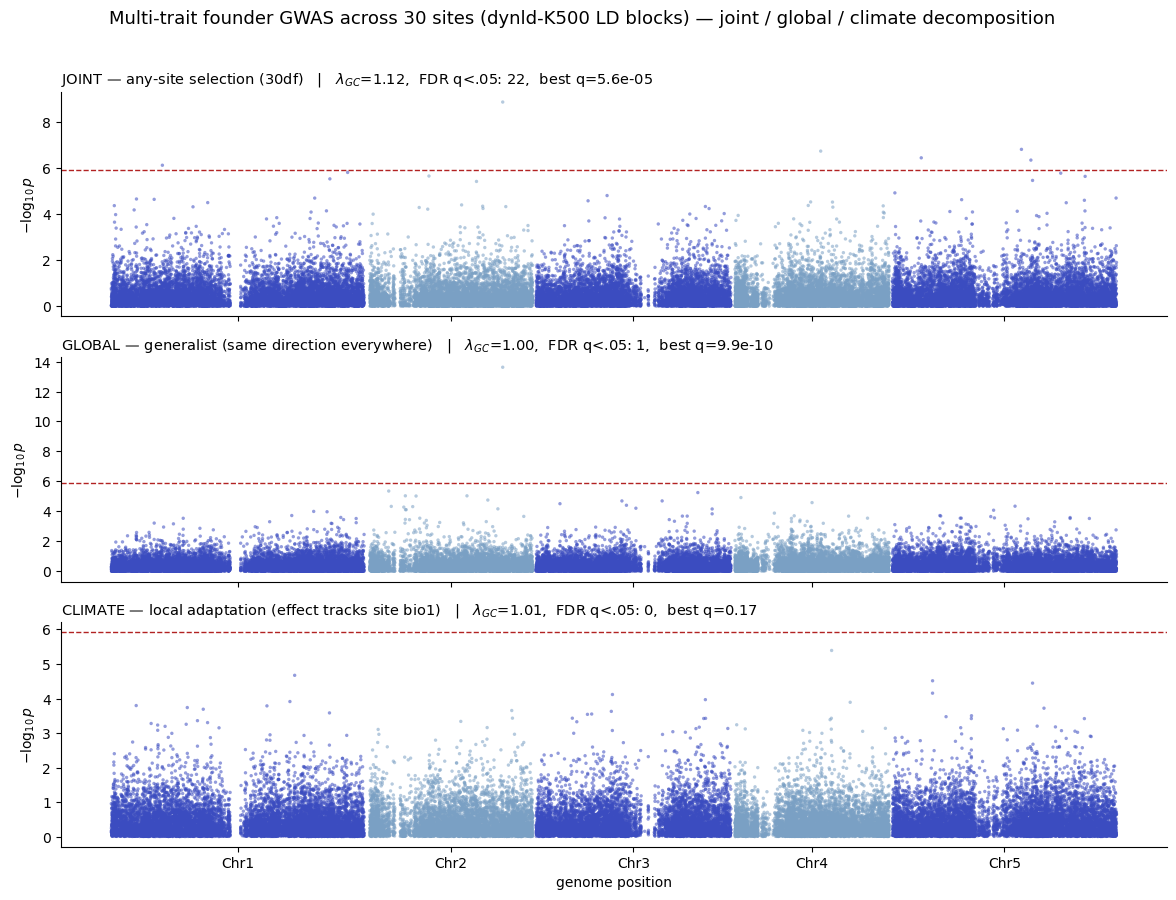

In [3]:
# 3-panel Manhattan: JOINT (any-site) / GLOBAL (generalist) / CLIMATE (local adaptation)
g2 = g.copy(); g2["mid"] = (g2.start+g2.end)/2
g2 = g2.sort_values(["chrom","start"]).reset_index(drop=True)
off, centers, x = 0.0, [], np.zeros(len(g2))
for ch in CHROMS:
    mk = (g2.chrom==ch).to_numpy()
    if not mk.any(): continue
    x[mk] = g2.mid[mk]+off; centers.append(off+g2.mid[mk].max()/2); off += g2.mid[mk].max()*1.02
g2["x"] = x
fig, ax = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
panels = [("p_joint", f"JOINT — any-site selection ({S}df)",   T["JOINT"]),
          ("p_global", "GLOBAL — generalist (same direction everywhere)", T["GLOBAL"]),
          ("p_clim",  "CLIMATE — local adaptation (effect tracks site bio1)", T["CLIMATE"])]
for axi, (col, tit, t) in zip(ax, panels):
    nlp = -np.log10(np.clip(g2[col], 1e-300, 1))
    for i, ch in enumerate(CHROMS):
        mk = (g2.chrom==ch).to_numpy()
        axi.scatter(g2.x[mk], nlp[mk], s=6, c=["#3b4cc0","#7aa0c4"][i%2], alpha=.55, edgecolors="none")
    axi.axhline(-np.log10(bonf), color="firebrick", lw=1, ls="--")
    axi.set_ylabel(r"$-\log_{10}p$")
    axi.set_title(f"{tit}   |   $\lambda_{{GC}}$={t['lam']:.2f},  FDR q<.05: {t['n_fdr']},  best q={t['best_q']:.2g}",
                  loc="left", fontsize=10.5)
    axi.spines[["top","right"]].set_visible(False)
ax[2].set_xticks(centers); ax[2].set_xticklabels(CHROMS); ax[2].set_xlabel("genome position")
fig.suptitle(f"Multi-trait founder GWAS across {S} sites ({BLOCKS}) — joint / global / climate decomposition",
             fontsize=13, y=0.995)
fig.tight_layout(rect=[0,0,1,0.98]); plt.show()

## The cross-site covariance C the meta-analysis whitens out

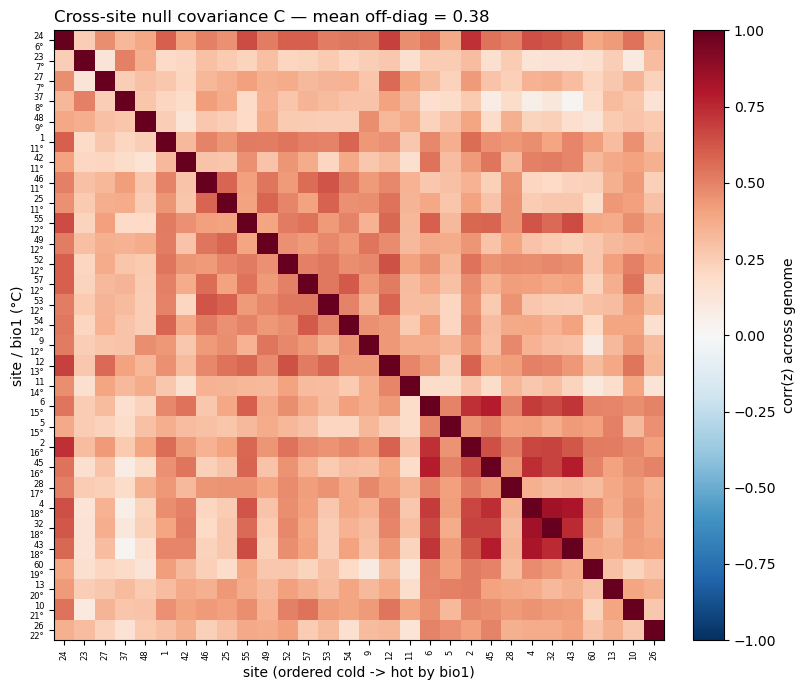

In [4]:
# Cross-site covariance C (sites ordered by bio1, cold -> hot). Mean off-diagonal ~0.38: the gardens
# share a broad correlated selection background (one clade tends to win in many places) -> exactly the
# nuisance the Bolormaa C^-1 whitening removes before asking generalist-vs-climate.
o = np.argsort(bio1); Co = C[np.ix_(o, o)]; lab = [f"{sites[i]}\n{bio1[i]:.0f}\u00b0" for i in o]
fig, ax = plt.subplots(figsize=(8.4, 7))
im = ax.imshow(Co, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(S)); ax.set_xticklabels([str(sites[i]) for i in o], fontsize=6, rotation=90)
ax.set_yticks(range(S)); ax.set_yticklabels(lab, fontsize=6)
ax.set_xlabel("site (ordered cold -> hot by bio1)"); ax.set_ylabel("site / bio1 (\u00b0C)")
ax.set_title(f"Cross-site null covariance C — mean off-diag = {meta['mean_cross_site_C']:.2f}", loc="left")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="corr(z) across genome")
plt.tight_layout(); plt.show()

## STAGE 2 — site-climate permutation null (climate contrast)

reproduced STAGE-2 (N_PERM=10000): FWER p(top)=0.262 (json 0.262); excess p=0.088 (json 0.088)


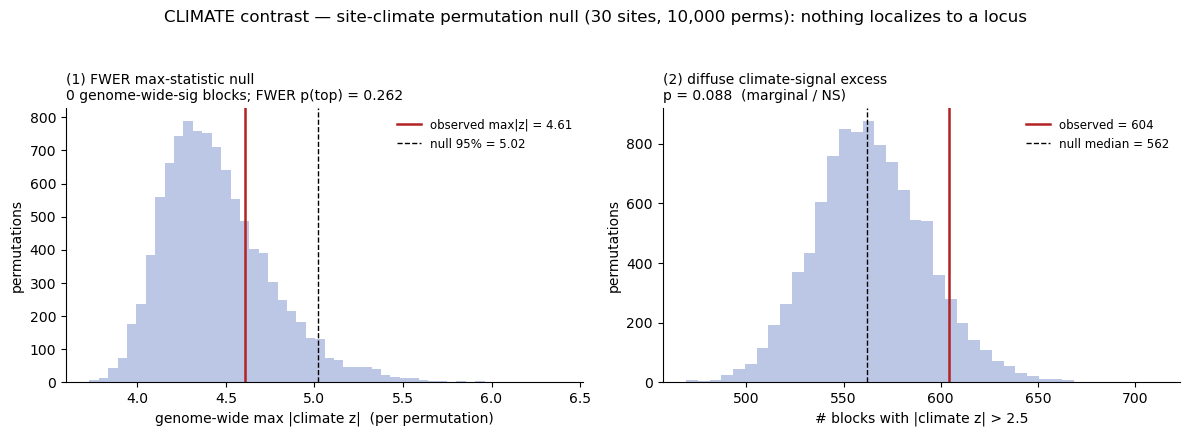

In [5]:
# STAGE 2 — site->climate permutation null (recomputed here; deterministic seed=0, ~seconds of matvecs).
# Permuting bio1 across sites is the EXACT exchangeable null for the CLIMATE contrast (GLOBAL/JOINT are
# invariant to which site is which). This calibrates the parametric STAGE-1 climate p-values genome-wide.
N_PERM = int(perm["n_perm"]); THR = perm["thr"]
Cinv = np.linalg.pinv(C); one = np.ones(S); dg = float(one@Cinv@one); ZC = Z@Cinv
def clim_z(b):
    c0 = (b-b.mean())/b.std(); c = c0 - (float(one@Cinv@c0)/dg)*one; dc = float(c@Cinv@c)
    return (ZC@c)/np.sqrt(dc)
obs = clim_z(bio1); obs_max = float(np.abs(obs).max()); obs_nexc = int((np.abs(obs)>THR).sum())
rng = np.random.default_rng(int(perm["seed"]))
null_max = np.empty(N_PERM); null_nexc = np.empty(N_PERM, int)
for k in range(N_PERM):
    a = np.abs(clim_z(rng.permutation(bio1))); null_max[k] = a.max(); null_nexc[k] = int((a>THR).sum())
fwer_thr = float(np.quantile(null_max, 0.95)); p_top = float((null_max>=obs_max).mean())
p_excess = float((null_nexc>=obs_nexc).mean())
print(f"reproduced STAGE-2 (N_PERM={N_PERM}): FWER p(top)={p_top:.3f} (json {perm['fwer_p_top']:.3f}); "
      f"excess p={p_excess:.3f} (json {perm['p_excess']:.3f})")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
ax[0].hist(null_max, bins=50, color="#bcc7e6", edgecolor="none")
ax[0].axvline(obs_max, color="firebrick", lw=1.8, label=f"observed max|z| = {obs_max:.2f}")
ax[0].axvline(fwer_thr, color="k", lw=1, ls="--", label=f"null 95% = {fwer_thr:.2f}")
ax[0].set_xlabel("genome-wide max |climate z|  (per permutation)"); ax[0].set_ylabel("permutations")
ax[0].set_title(f"(1) FWER max-statistic null\n0 genome-wide-sig blocks; FWER p(top) = {p_top:.3f}",
                fontsize=10, loc="left")
ax[0].legend(fontsize=8.5, frameon=False); ax[0].spines[["top","right"]].set_visible(False)
ax[1].hist(null_nexc, bins=40, color="#bcc7e6", edgecolor="none")
ax[1].axvline(obs_nexc, color="firebrick", lw=1.8, label=f"observed = {obs_nexc}")
ax[1].axvline(np.median(null_nexc), color="k", lw=1, ls="--", label=f"null median = {np.median(null_nexc):.0f}")
ax[1].set_xlabel(f"# blocks with |climate z| > {THR}"); ax[1].set_ylabel("permutations")
ax[1].set_title(f"(2) diffuse climate-signal excess\np = {p_excess:.3f}  (marginal / NS)", fontsize=10, loc="left")
ax[1].legend(fontsize=8.5, frameon=False); ax[1].spines[["top","right"]].set_visible(False)
fig.suptitle(f"CLIMATE contrast — site-climate permutation null ({S} sites, {N_PERM:,} perms): "
             f"nothing localizes to a locus", fontsize=12)
fig.tight_layout(rect=[0,0,1,0.94]); plt.show()

## The local-adaptation signal that survives — at the clade level (same 30 sites)

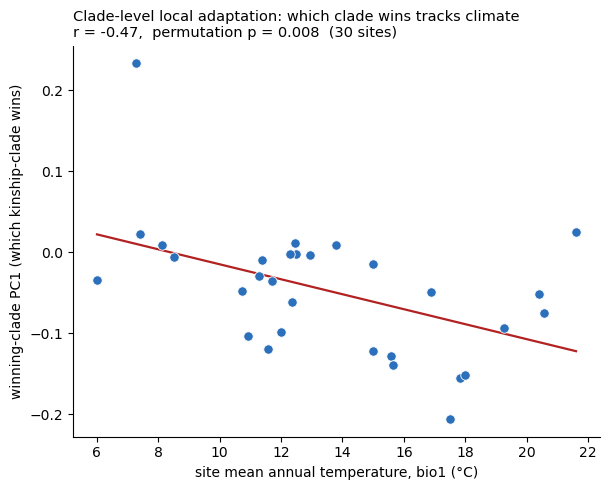

In [6]:
# The local-adaptation signal that DOES survive — at the clade level, not the locus level.
# SAME 30 sites + SAME trait as the GWAS above (recomputed by cross_site_winners_multisite.py; the
# original cross_site_winners.csv was a stricter 17-site subset on a logit fixed-gen trait). For each
# site take the kinship-clade that wins (selection-weighted PC1 of the winning founders) and correlate
# it with the garden's bio1: does which clade wins track climate, even though no single block does?
csw = pd.read_csv(f"{H}/cross_site_winners_30{SUFFIX}.csv")
cj  = json.load(open(f"{H}/cross_site_winners_30{SUFFIX}.json"))
mfin = np.isfinite(csw.bio1) & np.isfinite(csw.win_pc1)
xx, yy = csw.bio1[mfin].to_numpy(), csw.win_pc1[mfin].to_numpy()
r = cj["pc1"]["r"]; pp = cj["pc1"]["perm_p"]
fig, ax = plt.subplots(figsize=(6.2, 5))
ax.scatter(xx, yy, s=46, c="#2c6fbb", edgecolors="white", linewidths=.6, zorder=3)
b1, b0 = np.polyfit(xx, yy, 1); xs = np.array([xx.min(), xx.max()])
ax.plot(xs, b0+b1*xs, color="firebrick", lw=1.6, zorder=2)
ax.set_xlabel("site mean annual temperature, bio1 (\u00b0C)")
ax.set_ylabel("winning-clade PC1 (which kinship-clade wins)")
ax.set_title(f"Clade-level local adaptation: which clade wins tracks climate\n"
             f"r = {r:.2f},  permutation p = {pp:.3f}  ({len(xx)} sites)", loc="left", fontsize=10.5)
ax.spines[["top","right"]].set_visible(False); plt.tight_layout(); plt.show()

## Top blocks per contrast

In [7]:
# Top blocks per contrast. JOINT = real among-site selection; GLOBAL = the one very strong
# generalist locus (Chr2:16.07Mb, q~1e-9); CLIMATE top barely dents q (best ~0.17 -> nothing localizes).
def topk(col_p, col_q, cols, k=8):
    return g.sort_values(col_p).head(k)[["chrom","start","end","mac"]+cols].reset_index(drop=True)
print("JOINT — strongest among-site selection:")
display(topk("p_joint","q_joint",["chi2_joint","p_joint","q_joint"]))
print("\nGLOBAL — strongest generalist:")
display(topk("p_global","q_global",["z_global","p_global","q_global"]))
print("\nCLIMATE — strongest climate-leaning (note q stays high):")
display(topk("p_clim","q_clim",["z_clim","p_clim","q_clim"]))

JOINT — strongest among-site selection:


,chrom,start,end,mac,chi2_joint,p_joint,q_joint
0,Chr2,16069881,16070230,3.0,100.854174,1.360402e-09,0.000056
1,Chr5,15533428,15536355,5.0,87.532865,1.546055e-07,0.002524
2,Chr4,10323461,10326835,4.0,87.024777,1.841842e-07,0.002524
3,Chr5,3481054,3481090,6.0,85.060634,3.608508e-07,0.003709
4,Chr5,16669411,16669584,12.0,84.393254,4.527860e-07,0.003723
5,Chr1,6149443,6154222,3.0,82.872434,7.571476e-07,0.005188
6,Chr1,28440513,28440622,4.0,80.722840,1.554342e-06,0.008602
7,Chr5,20260494,20260936,4.0,80.500167,1.673712e-06,0.008602



GLOBAL — strongest generalist:


,chrom,start,end,mac,z_global,p_global,q_global
0,Chr2,16069881,16070230,3.0,-7.627351,2.396258e-14,9.851976e-10
1,Chr2,2355052,2355934,75.0,4.592257,4.384785e-06,6.464635e-02
2,Chr3,19470754,19472210,13.0,-4.542297,5.564466e-06,6.464635e-02
3,Chr2,4341565,4372683,24.0,-4.436857,9.128183e-06,6.464635e-02
4,Chr2,11768206,11772472,5.0,-4.436284,9.152495e-06,6.464635e-02
5,Chr2,5640349,5649312,4.0,-4.429751,9.434210e-06,6.464635e-02
6,Chr4,727321,727364,4.0,-4.378744,1.193651e-05,7.010823e-02
7,Chr2,14273970,14283313,69.0,-4.294517,1.750739e-05,8.246095e-02



CLIMATE — strongest climate-leaning (note q stays high):


,chrom,start,end,mac,z_clim,p_clim,q_clim
0,Chr4,11637341,11641542,18.0,4.608709,0.000004,0.166585
1,Chr1,22066491,22066548,6.0,4.251063,0.000021,0.368393
2,Chr5,4841445,4841487,27.0,-4.168688,0.000031,0.368393
3,Chr5,16870903,16871628,12.0,4.132774,0.000036,0.368393
4,Chr5,4835216,4841289,28.0,-3.976176,0.000070,0.524802
5,Chr3,9196652,9197783,10.0,-3.954836,0.000077,0.524802
6,Chr3,20378493,20378592,25.0,3.872142,0.000108,0.561559
7,Chr1,21489721,21501632,20.0,-3.841047,0.000123,0.561559


## Genes under the JOINT-significant blocks

The JOINT (any-site selection) contrast is the only one with a meaningful set of FDR-significant blocks
(GLOBAL = 1, CLIMATE = 0). Here we annotate each **FDR $q<0.05$** JOINT block with the TAIR10
protein-coding genes its haploblock span overlaps, flag the stricter Bonferroni subset, and flatten to a
**dataset of significant genes** — with the **gene symbol + function** pulled live from the Ensembl REST
API (the TAIR10 GFF only carries the AT-locus id). Note these are LD blocks, so a hit tags an LD region,
not a single causal gene; treat the per-block gene lists as candidates, not resolved targets.

In [8]:
import sys
sys.path.insert(0, "analysis/grenenet_gea"); import lib
genes = lib.load_genes()
sig = g[g.q_joint < 0.05].copy().sort_values("q_joint").reset_index(drop=True)   # FDR-significant JOINT
sig["bonferroni"] = sig.p_joint < bonf
# overlap each block's [start,end] span with genes (flank=0: dynld blocks already span an LD region)
blk = sig[["chrom","start","end","mac","chi2_joint","p_joint","q_joint","bonferroni"]].copy()
blk["pos"] = blk.start; blk["ref_len"] = (blk.end - blk.start).clip(lower=1)
ann = lib.annotate_svs(blk, flank=0, genes=genes)
print(f"JOINT FDR q<0.05: {len(sig)} blocks ({int(sig.bonferroni.sum())} also Bonferroni) | "
      f"{int((ann.n_genes>0).sum())} blocks overlap >=1 gene | {int(ann.n_genes.sum())} gene-overlaps total")
display(ann[["chrom","start","end","mac","chi2_joint","q_joint","bonferroni","n_genes","genes_all"]])

JOINT FDR q<0.05: 22 blocks (6 also Bonferroni) | 17 blocks overlap >=1 gene | 29 gene-overlaps total


,chrom,start,end,mac,chi2_joint,q_joint,bonferroni,n_genes,genes_all
0,Chr2,16069881,16070230,3.0,100.854174,0.000056,True,1,AT2G38360
1,Chr5,15533428,15536355,5.0,87.532865,0.002524,True,1,AT5G38790
2,Chr4,10323461,10326835,4.0,87.024777,0.002524,True,1,AT4G18810
3,Chr5,3481054,3481090,6.0,85.060634,0.003709,True,0,
4,Chr5,16669411,16669584,12.0,84.393254,0.003723,True,2,AT5G41680;AT5G41685
5,Chr1,6149443,6154222,3.0,82.872434,0.005188,True,3,AT1G17860;AT1G17870;AT1G17880
6,Chr1,28440513,28440622,4.0,80.722840,0.008602,False,0,
7,Chr5,20260494,20260936,4.0,80.500167,0.008602,False,1,AT5G49850
8,Chr2,7197048,7197522,24.0,79.633801,0.009478,False,0,
9,Chr5,23194641,23199442,18.0,79.533105,0.009478,False,3,AT5G57240;AT5G57250;AT5G57260


In [9]:
# flatten to one row per (block, gene) -> the dataset of significant genes
rows = []
for _, r in ann.iterrows():
    for gid in (r.genes_all.split(";") if r.genes_all else []):
        rows.append(dict(gene=gid, chrom=r.chrom, block_start=int(r.start), block_end=int(r.end),
                         q_joint=float(r.q_joint), bonferroni=bool(r.bonferroni)))
gd = pd.DataFrame(rows)
gd = gd.merge(genes[["gene","name","start","end","strand"]].rename(
              columns={"start":"gene_start","end":"gene_end"}), on="gene", how="left")
gd = gd.sort_values(["bonferroni","q_joint","chrom","gene_start"], ascending=[False,True,True,True]).reset_index(drop=True)
# functional annotation: gene symbol + description via Ensembl REST (one batch POST; falls back to
# AT-IDs if the compute node is offline -- the GFF `name` is only the AT-locus id, not the symbol).
import urllib.request as _u
ids = sorted(gd.gene.unique()); sym = {}; desc = {}
try:
    _req = _u.Request("https://rest.ensembl.org/lookup/id", data=json.dumps({"ids": ids}).encode(),
                      headers={"Content-Type": "application/json", "Accept": "application/json"})
    for gid, info in json.load(_u.urlopen(_req, timeout=90)).items():
        if info:
            sym[gid] = info.get("display_name", ""); desc[gid] = (info.get("description", "") or "").split(" [Source")[0]
    print(f"Ensembl: {sum(1 for gid in ids if sym.get(gid) and sym[gid]!=gid)}/{len(ids)} genes have a named symbol")
except Exception as e:
    print(f"[warn] Ensembl lookup unavailable ({type(e).__name__}) -> AT-IDs only")
gd["symbol"] = gd.gene.map(lambda x: "" if sym.get(x, x) == x else sym.get(x, ""))
gd["function"] = gd.gene.map(lambda x: desc.get(x, ""))
gd = gd[["gene","symbol","function","chrom","block_start","block_end","q_joint","bonferroni","gene_start","gene_end","strand"]]
gd.to_csv(f"{H}/multisite_joint_significant_genes{SUFFIX}.csv", index=False)
print(f"{gd.gene.nunique()} unique genes under the {len(sig)} JOINT-significant blocks "
      f"({gd[gd.bonferroni].gene.nunique()} under Bonferroni blocks) -> {H}/multisite_joint_significant_genes{SUFFIX}.csv")
display(gd)

Ensembl: 13/29 genes have a named symbol
29 unique genes under the 22 JOINT-significant blocks (8 under Bonferroni blocks) -> results/grenenet_gea/hapfreq/multisite_joint_significant_genes.csv


,gene,symbol,function,chrom,block_start,block_end,q_joint,bonferroni,gene_start,gene_end,strand
0,AT2G38360,PRA1.B4,prenylated RAB acceptor 1.B4,Chr2,16069881,16070230,0.000056,True,16069615,16070589,-
1,AT4G18810,,NAD(P)-binding Rossmann-fold superfamily protein,Chr4,10323461,10326835,0.002524,True,10322156,10325816,-
2,AT5G38790,,uncharacterized protein,Chr5,15533428,15536355,0.002524,True,15533785,15534180,+
3,AT5G41680,,Protein kinase superfamily protein,Chr5,16669411,16669584,0.003723,True,16667885,16669489,+
4,AT5G41685,,Mitochondrial outer membrane translocase compl...,Chr5,16669411,16669584,0.003723,True,16669149,16669723,-
5,AT1G17860,,Kunitz family trypsin and protease inhibitor p...,Chr1,6149443,6154222,0.005188,True,6149301,6150038,+
6,AT1G17870,EGY3,ethylene-dependent gravitropism-deficient and ...,Chr1,6149443,6154222,0.005188,True,6149939,6152222,-
7,AT1G17880,BTF3,basic transcription factor 3,Chr1,6149443,6154222,0.005188,True,6152409,6153982,-
8,AT5G49850,,Mannose-binding lectin superfamily protein,Chr5,20260494,20260936,0.008602,False,20259908,20262585,-
9,AT5G57240,ORP4C,OSBP(oxysterol binding protein)-related protei...,Chr5,23194641,23199442,0.009478,False,23193163,23195476,+


## More than temperature — precipitation and a bioclim PC

bio1 (mean annual T) is one axis; the two main climate axes for *Arabidopsis* local adaptation are
**temperature and precipitation**, so we also test **bio12 (annual precipitation)** and **PC1 of all 19
standardized bioclim variables** (a single composite climate gradient). For each axis we rerun *both*
levels on the same 30 sites: the **block-level** Bolormaa CLIMATE contrast (with a max-statistic
permutation FWER $p$) and the **clade-level** winning-clade-PC1 correlation (10k-perm $p$). Reusing the
saved $\mathbf Z$ and $\mathbf C$, this is just new contrast vectors — no EMMAX rerun.

In [10]:
from scipy import stats as _st
clim = lib.load_climate(); bio = clim.reindex(sites)
def _bh(pv):
    pv = np.asarray(pv); m_ = len(pv); o = pv.argsort(); q = np.empty(m_)
    q[o] = np.minimum.accumulate((pv[o]*m_/(np.arange(m_)+1))[::-1])[::-1]; return np.clip(q,0,1)
# bioclim PC1 across the 30 sites (standardize all 19 vars, SVD); sign so it tracks bio1
B = bio[[f"bio{i}" for i in range(1,20)]].to_numpy(float); Bz = (B - B.mean(0))/B.std(0)
Usv, sv, _ = np.linalg.svd(Bz - Bz.mean(0), full_matrices=False); bioPC1 = Usv[:,0]*sv[0]
if np.corrcoef(bioPC1, bio.bio1.to_numpy(float))[0,1] < 0: bioPC1 = -bioPC1
ve1 = sv[0]**2/(sv**2).sum()
axes = {"bio1 (temperature)": bio.bio1.to_numpy(float),
        "bio12 (precipitation)": bio.bio12.to_numpy(float),
        f"bioclim PC1 ({ve1:.0%} var)": bioPC1}
print("axis cross-correlations:  bio1~bio12 r=%.2f | bio1~PC1 r=%.2f | bio12~PC1 r=%.2f"
      % (np.corrcoef(axes["bio1 (temperature)"],axes["bio12 (precipitation)"])[0,1],
         np.corrcoef(axes["bio1 (temperature)"],bioPC1)[0,1],
         np.corrcoef(axes["bio12 (precipitation)"],bioPC1)[0,1]))
# block-level contrast machinery (reuse saved Z, C) + clade-level winners
Cinv = np.linalg.pinv(C); one = np.ones(S); dg = float(one@Cinv@one); ZC = Z@Cinv
def _cz(b):
    c0 = (b-b.mean())/b.std(); c = c0 - (float(one@Cinv@c0)/dg)*one; dc = float(c@Cinv@c)
    return (ZC@c)/np.sqrt(dc)
csw = pd.read_csv(f"{H}/cross_site_winners_30{SUFFIX}.csv").set_index("site").reindex(sites)
win = csw.win_pc1.to_numpy(float)
rows = []
for nm, b in axes.items():
    z = _cz(b); p = 2*_st.norm.sf(np.abs(z)); q = _bh(p); zmax = float(np.abs(z).max())
    rng = np.random.default_rng(0); nmax = np.array([np.abs(_cz(rng.permutation(b))).max() for _ in range(2000)])
    fwerp = float((nmax >= zmax).mean())
    rc = float(np.corrcoef(b, win)[0,1]); rng2 = np.random.default_rng(0)
    nd = np.array([abs(np.corrcoef(rng2.permutation(b), win)[0,1]) for _ in range(10000)])
    cp = float((nd >= abs(rc)).mean())
    rows.append(dict(axis=nm, block_lambda=float(np.median(z**2)/_st.chi2.ppf(0.5,1)),
                     block_best_q=float(q.min()), block_nFDR=int((q<0.05).sum()),
                     block_max_z=zmax, block_FWER_p=fwerp, clade_r=rc, clade_perm_p=cp))
axtab = pd.DataFrame(rows)
axtab.to_csv(f"{H}/multisite_climate_axes{SUFFIX}.csv", index=False)
display(axtab.round(4))

axis cross-correlations:  bio1~bio12 r=-0.45 | bio1~PC1 r=0.84 | bio12~PC1 r=-0.81


,axis,block_lambda,block_best_q,block_nFDR,block_max_z,block_FWER_p,clade_r,clade_perm_p
0,bio1 (temperature),1.0069,0.1666,0,4.6087,0.2625,-0.4720,0.0078
1,bio12 (precipitation),1.0093,0.4004,0,4.4229,0.5655,0.2275,0.2051
2,bioclim PC1 (47% var),1.0054,0.3569,0,4.3513,0.5845,-0.5152,0.0032


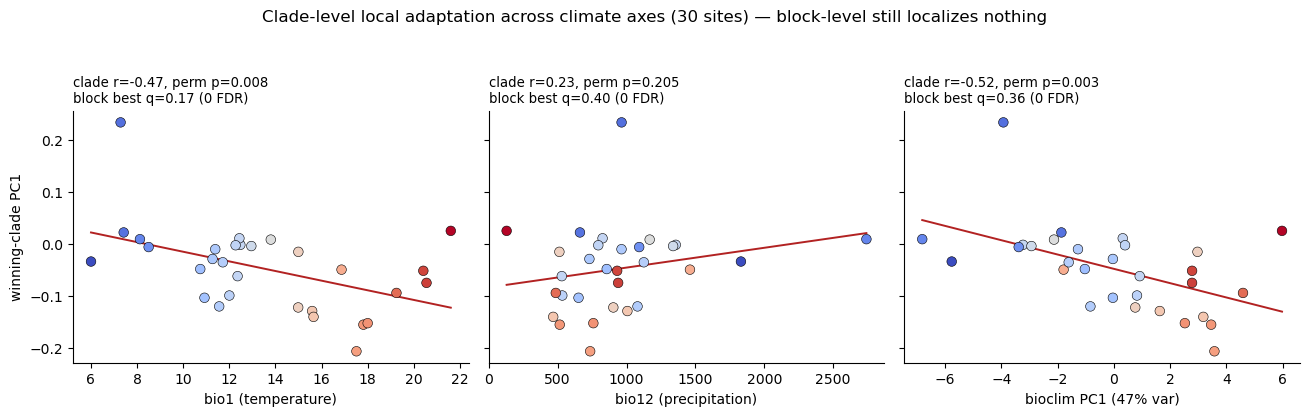

In [11]:
fig, axs = plt.subplots(1, len(axes), figsize=(4.4*len(axes), 4.2), sharey=True)
for ax_, (nm, b) in zip(axs, axes.items()):
    row = axtab[axtab.axis==nm].iloc[0]
    ax_.scatter(b, win, s=48, c=bio.bio1.to_numpy(float), cmap="coolwarm", edgecolors="k", lw=.4, zorder=3)
    bb1, bb0 = np.polyfit(b, win, 1); xs = np.array([b.min(), b.max()])
    ax_.plot(xs, bb0+bb1*xs, color="firebrick", lw=1.4, zorder=2)
    ax_.set_xlabel(nm); ax_.spines[["top","right"]].set_visible(False)
    ax_.set_title(f"clade r={row.clade_r:.2f}, perm p={row.clade_perm_p:.3f}\nblock best q={row.block_best_q:.2f} (0 FDR)",
                  loc="left", fontsize=9.5)
axs[0].set_ylabel("winning-clade PC1")
fig.suptitle("Clade-level local adaptation across climate axes (30 sites) — block-level still localizes nothing",
             fontsize=12)
fig.tight_layout(rect=[0,0,1,0.93]); plt.show()

## Bottom line

- **Generalist + among-site selection localizes.** GLOBAL surfaces the strongest generalist locus
  (best $q\approx$1e-9, 1 Bonferroni / 1 FDR); JOINT has 6 Bonferroni /
  22 FDR among-site hits. Calibration is clean ($\lambda_{GC}\approx1.0$–$1.1$).
- **Climate-differential selection does not localize.** 0 CLIMATE FDR hits (best $q=$0.17); the
  10k-perm null confirms it — no genome-wide-significant block (FWER $p=$0.26), diffuse excess only
  marginal/NS ($p=$0.088). Because a variable-window×climate confound would *inflate* climate
  signal, this null is **conservative** — and $\lambda_{\text{clim}}=$1.01 shows the confound didn't bite.
- **Robust to the climate axis (temperature, precipitation, composite).** Re-running the climate test on
  **bio1** (temperature), **bio12** (precipitation), and **PC1 of all 19 bioclim** (see the climate-axes
  table) leaves the **block** level localizing nothing on *every* axis, while the **clade**-level signal
  persists (strongest on the composite bioclim PC1). The broader axis strengthens the clade story without
  rescuing locus resolution.
- **But local adaptation is real — at the clade level.** On the **same 30 sites + same trait**,
  which kinship-clade wins tracks garden climate (winning-clade PC1 vs bio1, $|r|=$0.47, perm
  $p=$0.008). The per-founder selection vectors barely agree across sites (mean cross-site
  $r=$0.08) — *different* founders win in *different* climates, exactly the local-adaptation signature.

This is the **clade↔allele collinearity wall, demonstrated rather than asserted**: cross-site climate
GxE confirms local adaptation exists, but it does not break the collinearity enough to *localize* it to
founder-genome blocks. **Next:** the `TRAIT_GENS=1` uniform-window sensitivity (immune to the
variable-window×climate confound) is the remaining check on whether even the clade signal carries any
window-length artifact.